In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
alt_ids = {
    # ('wxf8ey6n', 'SM (Lorenz,MN:0,ObsN:0.1)'): {},
    # ('rt0ct08c', 'SM (EM,VE)'): {},
    ('69mjniig', 'SM (EM,VE,Training)'): {},
    ('9q6wja1u', 'FDM (Heun,OT,1,TrainingFree1)'): {},
    # ('r9m8k0u1', 'FDM (Heun,OT,1)'): {},
    # ('b6v774ub', 'FDM (Heun,OT,1,WeightedAndMCGuide)'): {},
    # ('59c9bun1', 'FDM (Heun,OT,1,WeightedAndLocal)'): {},
    # ('12kvjrqd', 'FDM (Heun,OT,1,TrainingFree1)'): {},
    # ('avel12di', 'FDM (Heun,OT,1,TrainingFree2)'): {},
    # ('cwe9q3op', 'FDM (Heun,OT,1,MCGuide(t=.1))'): {},
    # ('fcumci26', 'FDM (Heun,OT,1,MCGuide(t=.01))'): {},
    # ('h0ru6bdc', 'FDM (Heun,OT,1,MCGuide(t=.005))'): {},
    # ('c4173853', 'FDM (Heun,OT,1000)'): {},
    # ('zt01isgd', 'FDM (Heun,VE)'): {},
    # ('7xjj0irr', 'FM (Heun,VE)'): {},
    # ('3i9d4xei', 'FM (Heun,VE,ObsScore)'): {},
    # ('milrekro', 'FM (Heun,VE,ObsScore,LSC:1)'): {},
    # ('y17ihr53', 'FM (Heun,OT,ExSum)'): {},
    # ('1ccofu4x', 'FM (Heun,Var.Expld)'): {},
    # ('uddktup1', 'FM (Obs.Sample)'): {},
    # ('aaiadqy1', 'FM (Obs.Loss)'): {},
}

In [4]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('69mjniig', 'SM (EM,VE,Training)'): {'cfg': Conf(root_dir='/root/workspace/GitHub/Data-Assimilation-Flow-Matching',
                                                   out_dir='/root/workspace/out/dafm',
                                                   run_subdir='runs',
                                                   prediction_filename='trajectories.parquet',
                                                   device='cuda',
                                                   alt_id='69mjniig',
                                                   rng_seed=2376999025,
                                                   fit=True,
                                                   id=2,
                                                   dataset=DoubleWell(predicted_state_count=1000,
                                                                      time_step_count=100,
                                                                      time_step_count_drop_first=0,
               

In [5]:
for v in cfgs.values():
    v['trajectories'] = pd.read_parquet(v['cfg'].run_dir/v['cfg'].prediction_filename)

In [6]:
dim = 0
for v in cfgs.values():
    v['trajectories'][f'predicted_state_mean_{dim}'] = v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.contains(f'predicted_state_[0-9]+_dim_{dim}')]].mean(axis=1)

In [7]:
v['trajectories']

,times,true_state_dim_0,observation_dim_0,predicted_state_0_dim_0,predicted_state_1_dim_0,predicted_state_2_dim_0,predicted_state_3_dim_0,predicted_state_4_dim_0,predicted_state_5_dim_0,predicted_state_6_dim_0,...,predicted_state_991_dim_0,predicted_state_992_dim_0,predicted_state_993_dim_0,predicted_state_994_dim_0,predicted_state_995_dim_0,predicted_state_996_dim_0,predicted_state_997_dim_0,predicted_state_998_dim_0,predicted_state_999_dim_0,predicted_state_mean_0
0,0.000000,-1.008885,-1.037598,-0.958448,-1.061862,-1.049598,-0.800314,-0.866101,-1.035766,-0.689744,...,-1.389839,-0.865106,-1.102382,-1.238401,-0.958976,-1.227490,-1.172050,-1.407979,-0.986752,-1.003169
1,0.100000,-0.990047,-0.911333,-0.989432,-0.966175,-0.952656,-0.812766,-0.918285,-0.974421,-1.212776,...,-1.166341,-0.727885,-0.938230,-0.750172,-0.989862,-0.829542,-0.861619,-0.757588,-0.926746,-0.908534
2,0.200000,-0.963767,-0.811504,-0.780640,-0.859240,-0.850382,-0.654829,-0.709511,-0.842727,-0.535354,...,-1.137803,-0.708560,-0.891801,-0.996059,-0.781111,-0.987387,-0.946220,-1.155843,-0.803029,-0.812962
3,0.300000,-1.020289,-0.946174,-0.930056,-0.857749,-1.027925,-1.034791,-1.219677,-0.771247,-1.011353,...,-0.985237,-1.195629,-0.946800,-0.920757,-0.799604,-0.951284,-1.169418,-1.096430,-1.178442,-0.946144
4,0.400000,-1.034468,-0.936765,-0.999987,-0.812239,-0.677171,-0.817944,-0.776688,-1.089380,-0.866074,...,-0.977818,-0.632256,-1.258896,-0.861094,-0.571449,-1.101853,-0.666344,-1.131141,-1.012063,-0.940135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,9.600000,-0.861362,-0.609281,-0.595915,-0.447831,-0.698875,-0.644988,-0.637447,-0.784247,-0.800830,...,-0.704680,-0.650830,-0.673753,-0.888856,-0.514851,-0.615167,-0.677621,-0.798266,-0.491190,-0.619591
97,9.700000,-0.984532,-0.911681,-0.690722,-0.960529,-0.711478,-0.782107,-0.793423,-1.073716,-0.936885,...,-1.113692,-0.816721,-1.528587,-0.964444,-1.021081,-0.950587,-0.961460,-0.786772,-1.174389,-0.910963
98,9.800000,-0.970493,-1.089546,-1.321079,-0.858980,-1.231089,-1.083626,-0.798857,-1.080512,-1.192659,...,-1.432261,-1.058296,-0.991184,-1.080740,-1.030201,-1.035861,-1.237217,-0.971102,-0.978887,-1.085669
99,9.900001,-0.920799,-0.907130,-0.874707,-0.839446,-0.922632,-0.893929,-0.672667,-0.988230,-0.823940,...,-1.123351,-0.813457,-1.008920,-1.055778,-1.008680,-0.503229,-0.917760,-0.923843,-0.956165,-0.906691


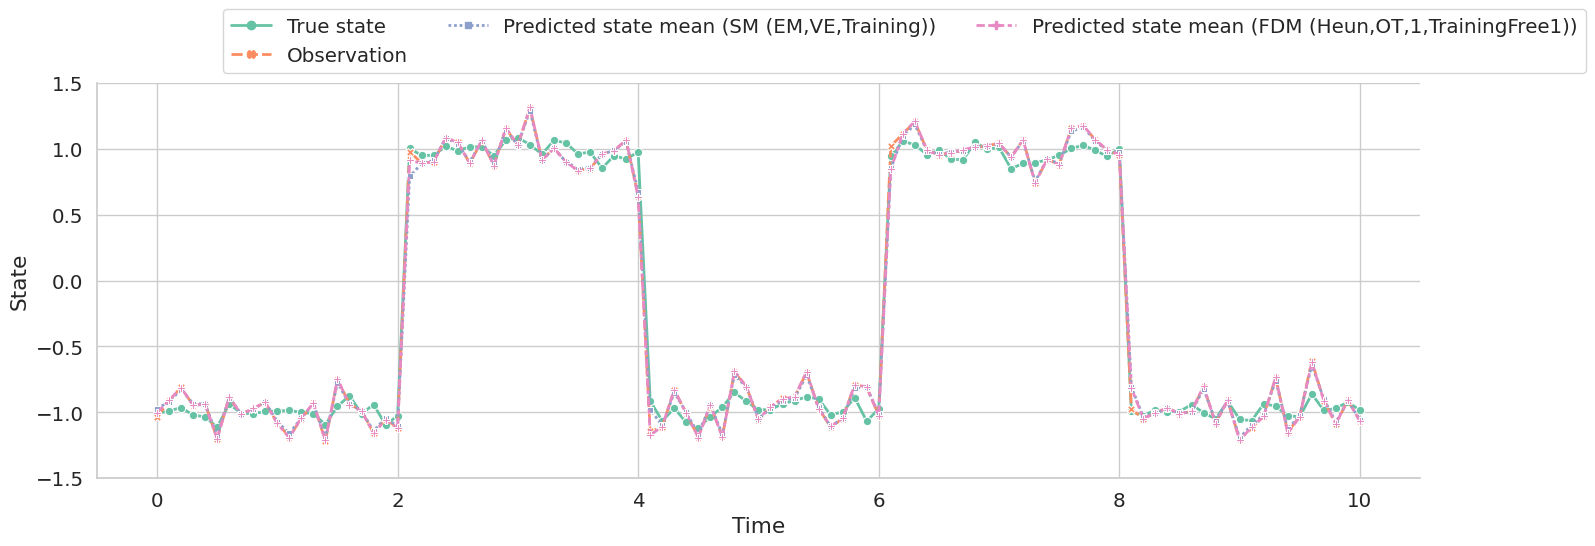

In [8]:
df_line = pd.concat([
    v['trajectories']['times'].rename('Time'),
    v['trajectories'][f'true_state_dim_{dim}'].rename('True state'),
    v['trajectories'][f'observation_dim_{dim}'].rename('Observation'),
    *(
        v['trajectories'][f'predicted_state_mean_{dim}'].rename(f'Predicted state mean ({k[1]})')
        for k, v in cfgs.items()
    )
], axis=1)
df_line_melt = df_line.melt(id_vars=['Time'], var_name='Source', value_name='State')
plot = (
    sns.relplot(
        data=df_line_melt,
        kind='line',
        x='Time',
        y='State',
        hue='Source',
        style='Source',
        markers=True,
        aspect=3,
        linewidth=2,
        # hue_order=['true_state', 'predicted_state_mean'],
    )
    .set(ylim=(-1.5, 1.5))
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=min(len(df_line_melt['Source'].unique()), 3),
    title='',
    bbox_to_anchor=(.455, 1.12),
    frameon=True,
    fancybox=True,
)

In [9]:
df = df_line
print('RMSE')
print()
print(df.transform(lambda x: x if x.name == 'Time' else x - df['True state']).pow(2).mean().pow(1/2))
print()
print('MAE')
df.transform(lambda x: x if x.name == 'Time' else x - df['True state']).abs().mean()
# (df.T - df['True state']).T.pow(2).sum()

RMSE

Time                                                    5.787919
True state                                              0.000000
Observation                                             0.112803
Predicted state mean (SM (EM,VE,Training))              0.105207
Predicted state mean (FDM (Heun,OT,1,TrainingFree1))    0.116940
dtype: float32

MAE


Time                                                    5.000000
True state                                              0.000000
Observation                                             0.090422
Predicted state mean (SM (EM,VE,Training))              0.084628
Predicted state mean (FDM (Heun,OT,1,TrainingFree1))    0.094234
dtype: float32

In [10]:
plots.save_all_subfigures(plot, 'Predictions')

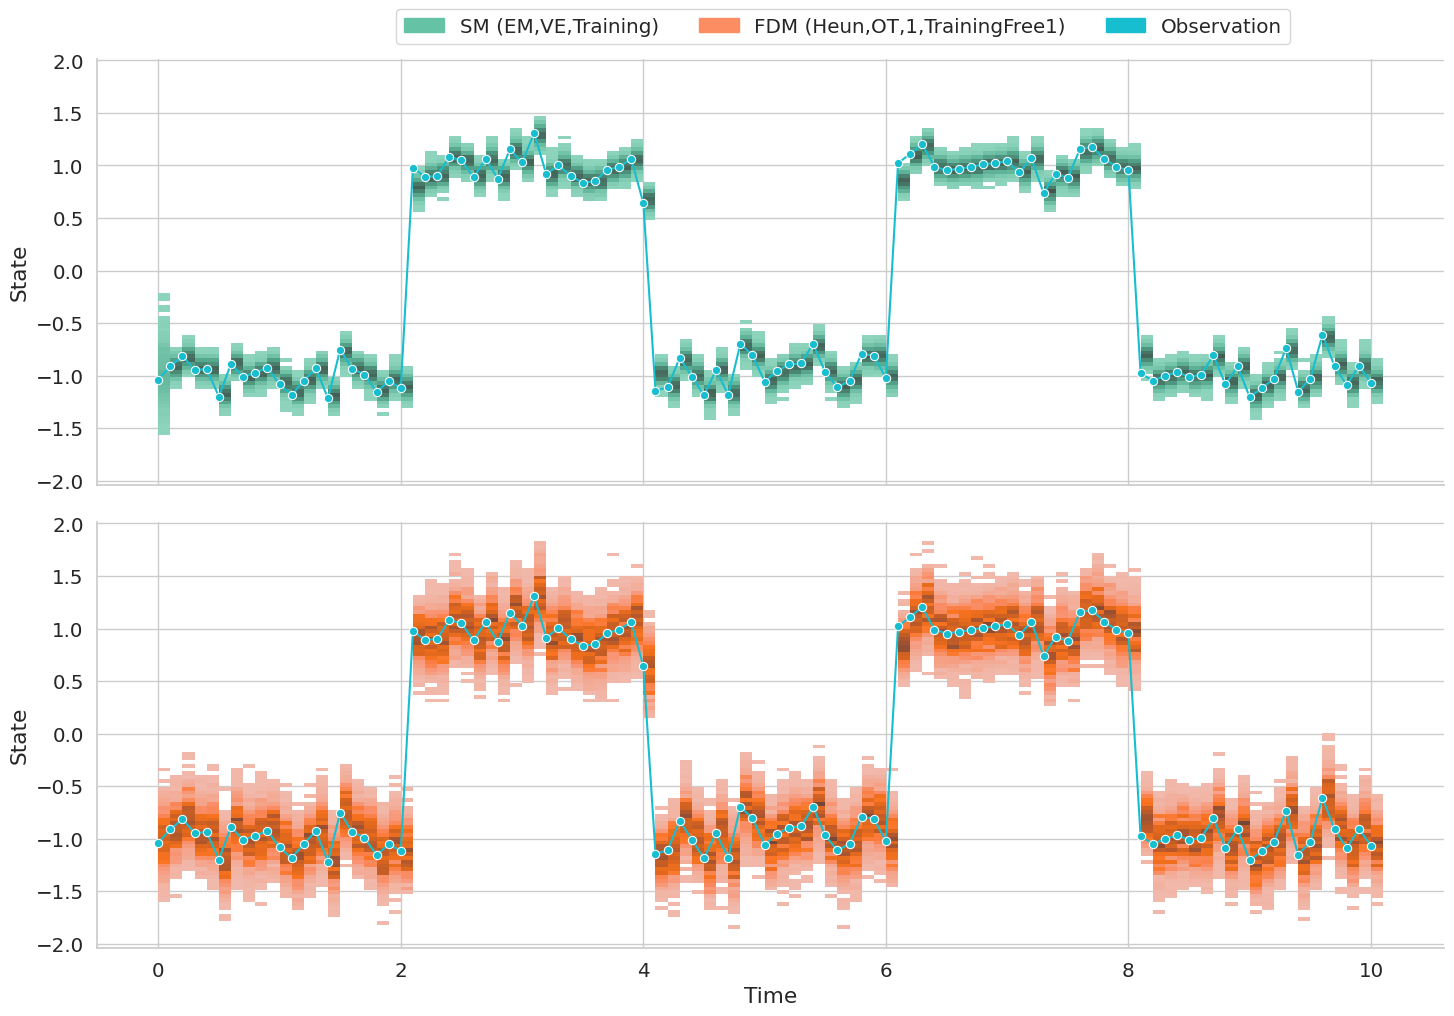

In [19]:
dim = 0
df_hist = (
    pd.concat([
        v['trajectories'] for v in cfgs.values()
    ], keys=[k[1] for k in cfgs], names=['Model'])
    .reset_index()
    .melt(id_vars=['Model', 'times'], var_name='Source', value_name='State', value_vars=v['trajectories'].columns[v['trajectories'].columns.str.startswith('predicted_state')])
    .rename(columns={'times': 'Time'})
)
#.melt(id_vars=['Time'], var_name='Source', value_name='State')
df_hist
plot = (
    sns.displot(
        data=df_hist,
        x='Time',
        y='State',
        row='Model',
        hue='Model',
        hue_order=[*df_hist['Model'].unique(), 'Observation'],# 'True state'],
        palette=[*sns.color_palette()[:len(df_hist['Model'].unique())], 'tab:cyan'],# 'tab:red'],
        bins=(v['trajectories']['times'], 101),
        binwidth=(v['trajectories']['times'].diff().iloc[-1], None),
        aspect=3,
        common_norm=False,
        # binrange=(None, (-3, 3)),
    )
    .set_titles('')
    # .set(xticks=[])
)
plot.map(
    sns.lineplot,
    data=df_line_melt.loc[(df_line_melt['Source'] == 'Observation'), ['Time', 'State', 'Source']],
    x='Time',
    y='State',
    color='tab:cyan',
    style='Source',
    markers=True,
)
# plot.map(
#     sns.lineplot,
#     data=df_line_melt.loc[(df_line_melt['Source'] == 'True state'), ['Time', 'State', 'Source']],
#     x='Time',
#     y='State',
#     color='tab:red',
#     style='Source',
#     markers=True,
# )
sns.move_legend(
    plot,
    loc='upper center',
    ncol=len(df_hist['Model'].unique()) + 1,
    title='',
    bbox_to_anchor=(.455, 1.03),
    frameon=True,
    fancybox=True,
)

In [12]:
plots.save_all_subfigures(plot, 'PredictedStateHistogram')

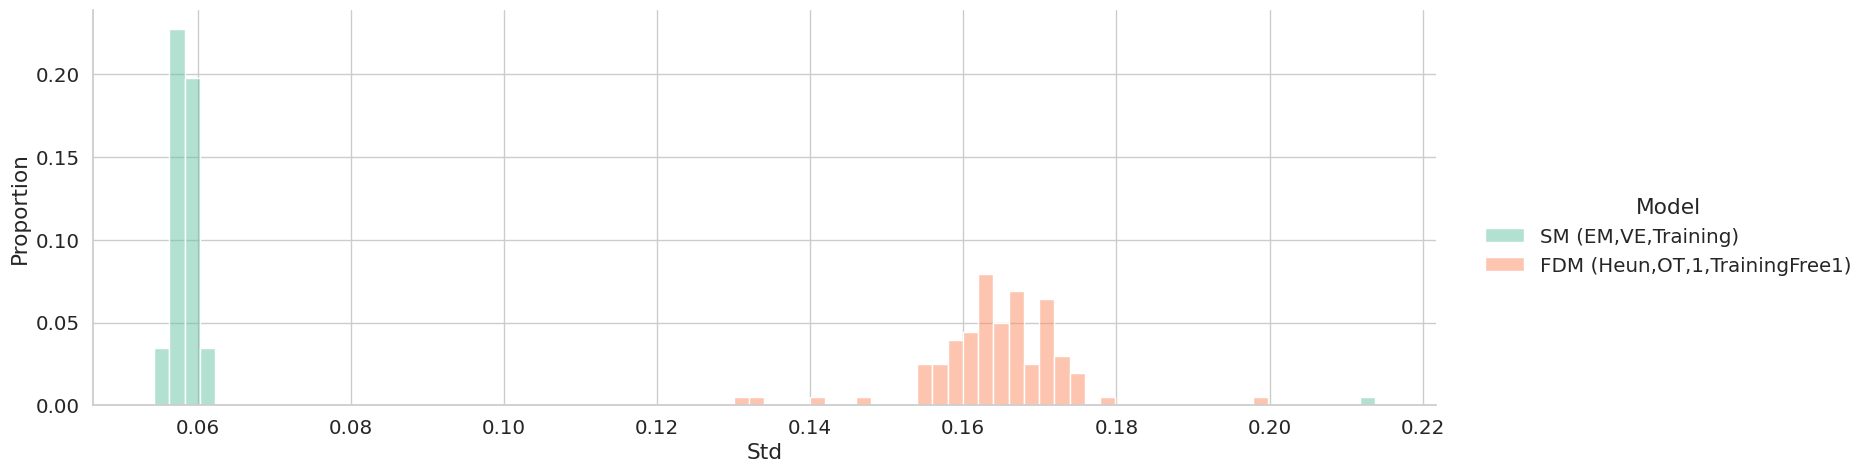

In [13]:
std = pd.concat([
    v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.startswith('predicted_state')]]
    .std(axis=1)
    .rename('Std')
    for k, v in cfgs.items()
], keys=[k[1] for k in cfgs], names=['Model']).reset_index()
plot = (
    sns.displot(
        data=std,
        x='Std',
        hue='Model',
        stat='proportion',
        aspect=3,
        bins=80,
    )
)
# plot.axes[0][0].set_xticks(np.arange(0, std['Std'].max() + .1, .1))
plot

In [14]:
std.loc[std['Model'] == 'FM (Obs.)']

,Model,level_1,Std


In [15]:
stats = pd.concat([
    v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.startswith('predicted_state')]]
    .std(axis=1, ddof=0)
    .describe()
    .rename(k[1])
    .to_frame().T
    for k, v in cfgs.items()
])
print(stats[stats.columns[stats.columns != 'count']].to_latex())

\begin{tabular}{lrrrrrrr}
\toprule
 & mean & std & min & 25% & 50% & 75% & max \\
\midrule
SM (EM,VE,Training) & 0.059709 & 0.015525 & 0.054286 & 0.057215 & 0.058219 & 0.059083 & 0.213639 \\
FDM (Heun,OT,1,TrainingFree1) & 0.164342 & 0.008486 & 0.130025 & 0.160573 & 0.164628 & 0.169552 & 0.198497 \\
\bottomrule
\end{tabular}

